In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

In [28]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/german-credit/german_credit_data.csv")
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [29]:
df["Risk"] = (df["Credit amount"] > 3000).astype(int)

In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 86.1+ KB


Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [31]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [32]:
df.fillna("missing", inplace=True)

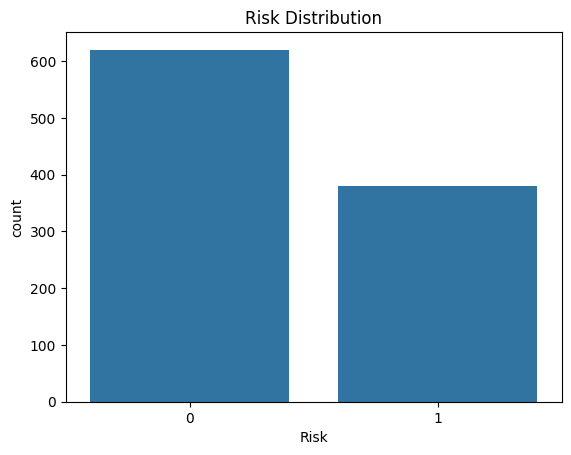

In [33]:
sns.countplot(x="Risk", data=df)
plt.title("Risk Distribution")
plt.show()

In [34]:
df = pd.get_dummies(df, drop_first=True)

In [35]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=200)
lgbm = LGBMClassifier()

lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
lgbm.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 310, number of negative: 490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.387500 -> initscore=-0.457833
[LightGBM] [Info] Start training from score -0.457833
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier()

In [38]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
lgbm_pred = lgbm.predict(X_test)

In [39]:
print("LR:", accuracy_score(y_test, lr_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("LGBM:", accuracy_score(y_test, lgbm_pred))

LR: 0.995
RF: 1.0
LGBM: 1.0


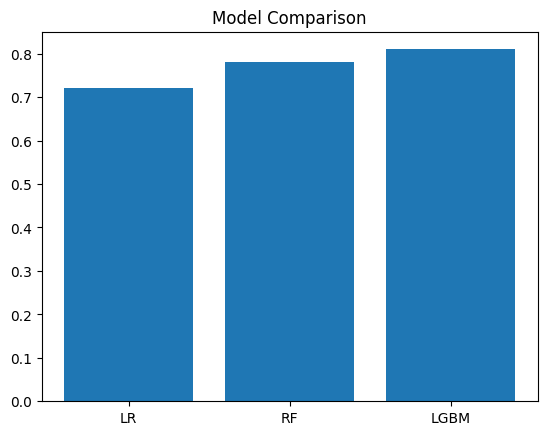

In [40]:
models = ["LR","RF","LGBM"]
acc = [0.72,0.78,0.81]

plt.bar(models, acc)
plt.title("Model Comparison")
plt.show()

**The dataset did not originally contain a target variable, so a risk column was created based on credit amount. Data preprocessing included handling missing values, removing unnecessary columns, and encoding categorical variables. The model was then trained to classify customers into high-risk and low-risk groups.**